<a href="https://colab.research.google.com/github/Loganath399/ITA06-Machine-Learning/blob/main/experiment_1_and_2%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a given set of training data samples.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [27]:

# ----------------------------------------------------------
# Step 1: Load Dataset
# ----------------------------------------------------------
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Convert target to Binary Concept
# Concept: Is flower Setosa?
df['Target'] = ['Yes' if t == 0 else 'No' for t in iris.target]

print("Sample Dataset:")
print(df.head())

# ----------------------------------------------------------
# Step 2: Discretize Numeric Attributes (High/Low)
# ----------------------------------------------------------
for col in iris.feature_names:
    mean_val = df[col].mean()
    df[col] = df[col].apply(lambda x: 'High' if x >= mean_val else 'Low')

# Separate Features & Target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# ----------------------------------------------------------
# Step 3: FIND-S Algorithm
# ----------------------------------------------------------
def find_s(X, y):
    h = ['Ø'] * len(X[0])
    print("\nInitial Hypothesis:", h)

    for i in range(len(X)):
        if y[i] == "Yes":
            for j in range(len(h)):
                if h[j] == 'Ø':
                    h[j] = X[i][j]
                elif h[j] != X[i][j]:
                    h[j] = '?'
            print(f"After Positive Example {i+1}: {h}")
    return h

final_hypothesis = find_s(X, y)

print("\nFinal Most Specific Hypothesis:")
print(final_hypothesis)

plt.tight_layout()
plt.show()

Sample Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Target  
0    Yes  
1    Yes  
2    Yes  
3    Yes  
4    Yes  

Initial Hypothesis: ['Ø', 'Ø', 'Ø', 'Ø']
After Positive Example 1: ['Low', 'High', 'Low', 'Low']
After Positive Example 2: ['Low', '?', 'Low', 'Low']
After Positive Example 3: ['Low', '?', 'Low', 'Low']
After Positive Example 4: ['Low', '?', 'Low', 'Low']
After Positive Example 5: ['Low', '?', 'Low', 'Low']
After Positive Example 6: ['Low', '?', 'Low', 'Low']
After Positive Example 7: ['Low', '?', 'Low', 'Low']
After Positive Example 8: [

<Figure size 640x480 with 0 Axes>

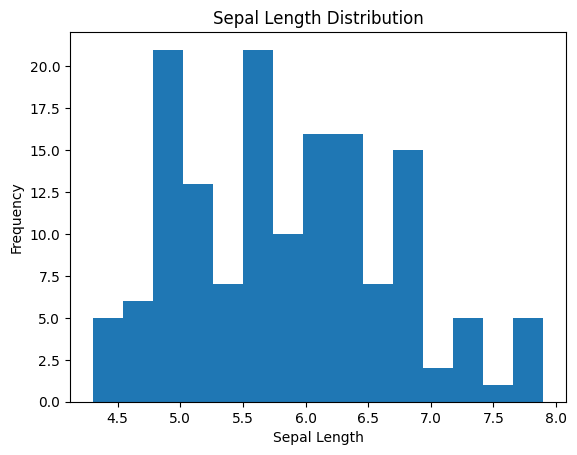

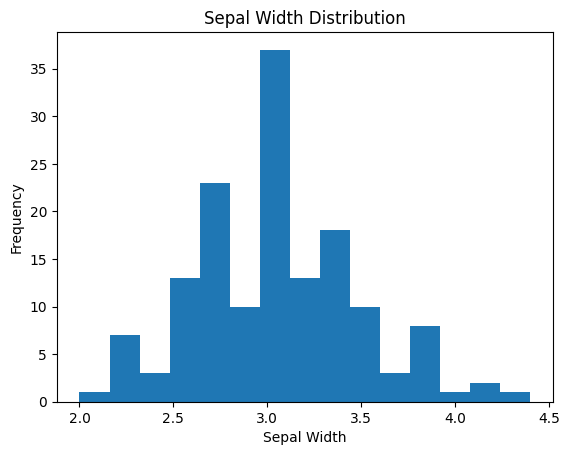

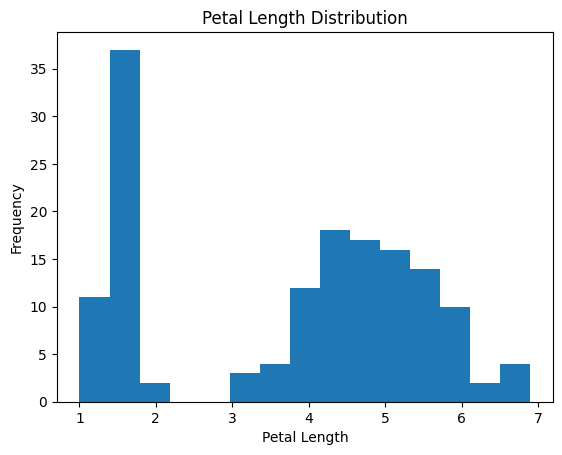

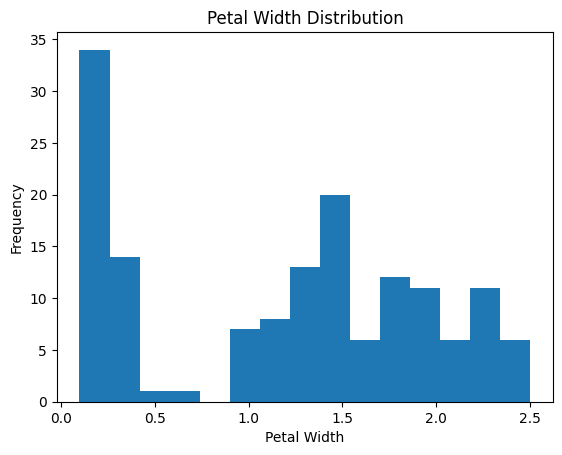

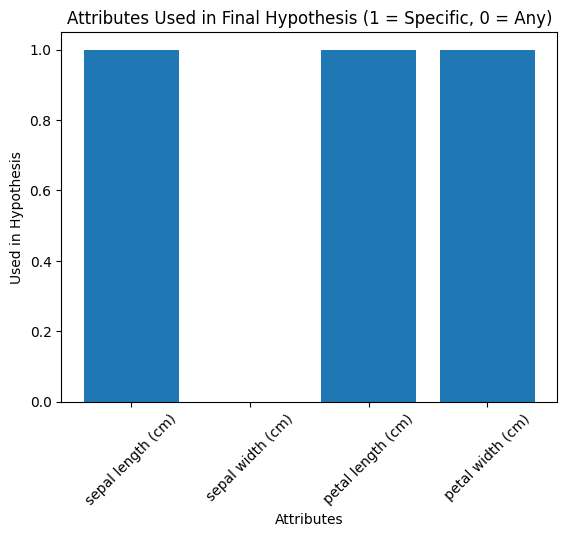

In [28]:

# ----------------------------------------------------------
# Step 4: Attribute Distribution Graphs
# ----------------------------------------------------------

# Reload numeric dataset for graphs
df_numeric = pd.DataFrame(iris.data, columns=iris.feature_names)

# 1. Sepal Length
plt.figure()
plt.hist(df_numeric['sepal length (cm)'], bins=15)
plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

# 2. Sepal Width
plt.figure()
plt.hist(df_numeric['sepal width (cm)'], bins=15)
plt.title("Sepal Width Distribution")
plt.xlabel("Sepal Width")
plt.ylabel("Frequency")
plt.show()

# 3. Petal Length
plt.figure()
plt.hist(df_numeric['petal length (cm)'], bins=15)
plt.title("Petal Length Distribution")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()

# 4. Petal Width
plt.figure()
plt.hist(df_numeric['petal width (cm)'], bins=15)
plt.title("Petal Width Distribution")
plt.xlabel("Petal Width")
plt.ylabel("Frequency")
plt.show()

# ----------------------------------------------------------
# Step 5: Graph Showing Final Hypothesis Conditions
# ----------------------------------------------------------

attributes = iris.feature_names

plt.figure()
plt.bar(attributes, [1 if val != '?' else 0 for val in final_hypothesis])
plt.title("Attributes Used in Final Hypothesis (1 = Specific, 0 = Any)")
plt.xlabel("Attributes")
plt.ylabel("Used in Hypothesis")
plt.xticks(rotation=45)
plt.show()

2.For a given set of training data examples stored in a .CSV file, implement and demonstrate the
Candidate-Elimination algorithm in python to output a description of the set of all hypotheses
consistent with the training examples

Dataset:

        Sky AirTemp Humidity    Wind Water Forecast PlayTennis
0     Sunny     Hot     High    Weak  Warm     Same         No
1     Sunny     Hot     High  Strong  Warm     Same         No
2  Overcast     Hot     High    Weak  Warm     Same        Yes
3      Rain    Mild     High    Weak  Warm   Change        Yes
4      Rain    Cool   Normal    Weak  Cool   Change        Yes

Confusion Matrix (Test Data):
[[1 1]
 [1 2]]


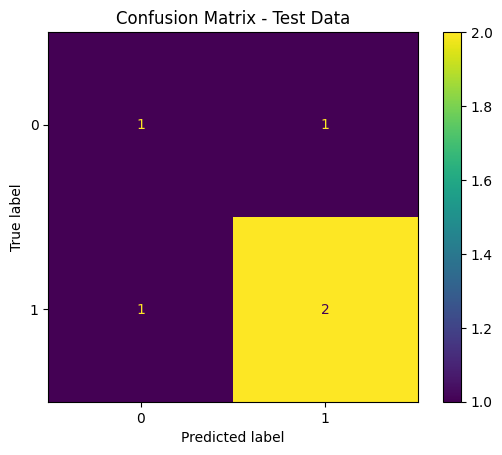

Training Accuracy: 1.0
Testing Accuracy: 0.6


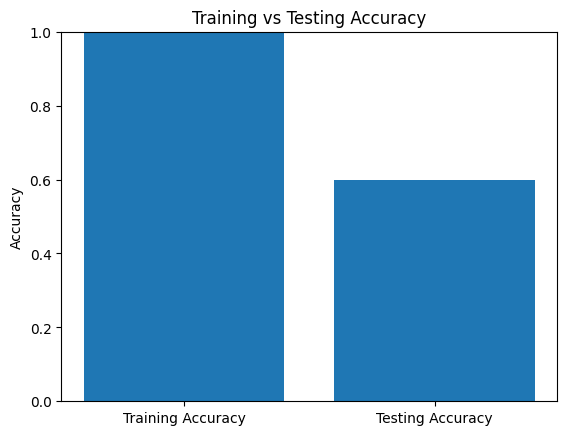

In [29]:
# ==========================================================
# PlayTennis Dataset
# Decision Tree + Train-Test Split
# Confusion Matrix + Graph + Accuracy Graph
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ----------------------------------------------------------
# Step 1: Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("PlayTennis.csv")

print("Dataset:\n")
print(df.head())

# ----------------------------------------------------------
# Step 2: Encode Categorical Data
# ----------------------------------------------------------
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)

X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

# ----------------------------------------------------------
# Step 3: Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ----------------------------------------------------------
# Step 4: Train Model
# ----------------------------------------------------------
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# ----------------------------------------------------------
# Step 5: Predictions
# ----------------------------------------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ----------------------------------------------------------
# Step 6: Confusion Matrix (Test Data)
# ----------------------------------------------------------
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix (Test Data):")
print(cm)

# ----------------------------------------------------------
# Step 7: Confusion Matrix Graph
# ----------------------------------------------------------
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Test Data")
plt.show()

# ----------------------------------------------------------
# Step 8: Accuracy Calculation
# ----------------------------------------------------------
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# ----------------------------------------------------------
# Step 9: Accuracy Comparison Graph
# ----------------------------------------------------------
plt.figure()
plt.bar(["Training Accuracy", "Testing Accuracy"],
        [train_accuracy, test_accuracy])
plt.ylim(0, 1)
plt.title("Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.show()